### Programming for Biomedical Informatics (INFR11260)
#### Semester 1 - Working with Notebooks & Git

##### Ian Simpson (ian.simpson@ed.ac.uk) 2025

#### Don't worry about the exact biological details of the code below, this is just to show you an example of how the notebooks we use will look and so that I can explain various features. If you do want to do the challenge and the end then great, but purely optional!

In [5]:
# Genomic information for various species

# I've commented out the "ul.request.urlretrieve...." lines to prevent them being downloaded many times as they are large.
# If you want to download them again, just remove the # symbol and run the code again.

# We are going to download genome scale annotation data directly from NCBI for 5 model organisms.

import pandas as pd
import urllib as ul
import numpy as np
import matplotlib
import os

resources = [
    ('https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Mammalia/Homo_sapiens.gene_info.gz', 'data/Homo_sapiens.gene_info.gz' ),
    ('https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Mammalia/Mus_musculus.gene_info.gz','data/Mus_musculus.gene_info.gz'),
    ('https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Mammalia/Rattus_norvegicus.gene_info.gz','data/Rattus_norvegicus.gene_info.gz'),
    ('https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Invertebrates/Drosophila_melanogaster.gene_info.gz','data/Drosophila_melanogaster.gene_info.gz'),
    ('https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Fungi/Saccharomyces_cerevisiae.gene_info.gz','data/Saccharomyces_cerevisiae.gene_info.gz')
]
data_folder = 'data'

if not os.path.exists(data_folder):
    os.makedirs(data_folder)

for url, file_name in resources:
    if not os.path.exists(file_name):
        print(f"Downloading {file_name}...")
        ul.request.urlretrieve(url, file_name)
    else:
        print("File already downloaded, skipping download")

print("download complete")


# # #human
# ul.request.urlretrieve('https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Mammalia/Homo_sapiens.gene_info.gz','data/Homo_sapiens.gene_info.gz')

# # #mouse
# ul.request.urlretrieve('https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Mammalia/Mus_musculus.gene_info.gz','data/Mus_musculus.gene_info.gz')

# # #rat
# ul.request.urlretrieve('https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Mammalia/Rattus_norvegicus.gene_info.gz','data/Rattus_norvegicus.gene_info.gz')

# # #fruitfly
# ul.request.urlretrieve('https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Invertebrates/Drosophila_melanogaster.gene_info.gz','data/Drosophila_melanogaster.gene_info.gz')

# # #yeast
# ul.request.urlretrieve('https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Fungi/Saccharomyces_cerevisiae.gene_info.gz','data/Saccharomyces_cerevisiae.gene_info.gz')

File already downloaded, skipping download
File already downloaded, skipping download
File already downloaded, skipping download
File already downloaded, skipping download
File already downloaded, skipping download
download complete


### Why are we studying different animals:
- Genes that drive mechanisms across different animals can be 'conservative' e.g. the mechanisms are very similar across different animals
- Sequencing the Human genome took 20 yearsd and millions of dollars


In [6]:
#read the gene_info files into Pandas data frames
human_df = pd.read_csv('data/Homo_sapiens.gene_info.gz', compression='gzip', header=0, sep='\t')
mouse_df = pd.read_csv('data/Mus_musculus.gene_info.gz', compression='gzip', header=0, sep='\t')
rat_df = pd.read_csv('data/Rattus_norvegicus.gene_info.gz', compression='gzip', header=0, sep='\t')
fruitfly_df = pd.read_csv('data/Drosophila_melanogaster.gene_info.gz', compression='gzip', header=0, sep='\t')
yeast_df = pd.read_csv('data/Saccharomyces_cerevisiae.gene_info.gz', compression='gzip', header=0, sep='\t')

In [7]:
#show the first few lines of the dataframe
human_df.head()

,#tax_id,GeneID,Symbol,LocusTag,Synonyms,dbXrefs,chromosome,map_location,description,type_of_gene,Symbol_from_nomenclature_authority,Full_name_from_nomenclature_authority,Nomenclature_status,Other_designations,Modification_date,Feature_type
0,9606,1,A1BG,-,A1B|ABG|GAB|HYST2477,MIM:138670|HGNC:HGNC:5|Ensembl:ENSG00000121410...,19,19q13.43,alpha-1-B glycoprotein,protein-coding,A1BG,alpha-1-B glycoprotein,O,alpha-1B-glycoprotein|HEL-S-163pA|epididymis s...,20250819,-
1,9606,2,A2M,-,A2MD|CPAMD5|FWP007|S863-7,MIM:103950|HGNC:HGNC:7|Ensembl:ENSG00000175899...,12,12p13.31,alpha-2-macroglobulin,protein-coding,A2M,alpha-2-macroglobulin,O,alpha-2-macroglobulin|C3 and PZP-like alpha-2-...,20250909,-
2,9606,9,NAT1,-,AAC1|MNAT|NAT-1|NATI,MIM:108345|HGNC:HGNC:7645|Ensembl:ENSG00000171...,8,8p22,N-acetyltransferase 1,protein-coding,NAT1,N-acetyltransferase 1,O,arylamine N-acetyltransferase 1|N-acetyltransf...,20250909,-
3,9606,10,NAT2,-,AAC2|NAT-2|PNAT,MIM:612182|HGNC:HGNC:7646|Ensembl:ENSG00000156...,8,8p22,N-acetyltransferase 2,protein-coding,NAT2,N-acetyltransferase 2,O,arylamine N-acetyltransferase 2|N-acetyltransf...,20250909,-
4,9606,11,NATP,-,AACP|NATP1,HGNC:HGNC:15|AllianceGenome:HGNC:15,8,8p22,N-acetyltransferase pseudogene,pseudo,NATP,N-acetyltransferase pseudogene,O,arylamide acetylase pseudogene,20250819,-


### What the head() show us:
- Focuses on genes
- The gene IDs are immutable sessions
- Each session uniquely identify genes
- Incredibly important for mapping across different datasets
- Some genes are given different names across different datasets
- Physical info - what kind of gene, location, what chromosone is it on


In [9]:
# count the number of genes per chromosome
human_chromosomes = human_df['chromosome'].value_counts().rename_axis('chromosome').reset_index(name='gene_count')

# show the first few lines
human_chromosomes.head()

,chromosome,gene_count
0,1,18332
1,2,13862
2,6,10603
3,3,10562
4,7,10047


### What summary shows us:
- There are 18000 genes on chromosone 1, and there are only 20000 protein coding genomes e.g. there are a lot of non-protein coding genomes

In [10]:
# show the size of the dataframe
print(human_df.shape)

(193686, 16)


<Axes: xlabel='chromosome', ylabel='gene count'>

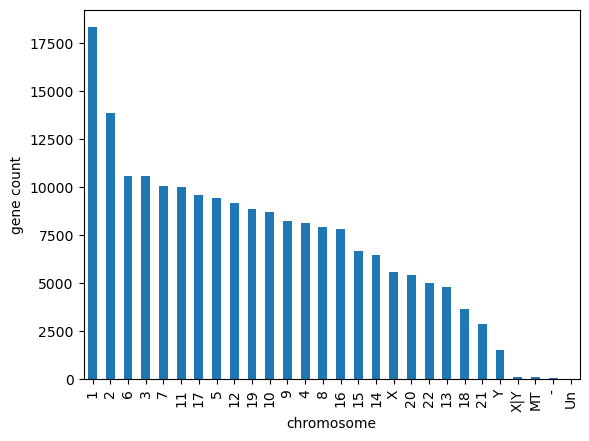

In [11]:
#plot a basic bar-plot
sorted_counts = human_chromosomes.sort_values('gene_count',ascending=False)
sorted_counts.plot.bar(x='chromosome', y='gene_count', ylabel='gene count', xlabel='chromosome', legend=False)

### Analysis of Counts:
- There are a lot less genes on the Y (male) chromosone than the X (female)


          counts
human     193686
mouse     112310
rat        47817
fruitfly   25079
yeast       6514


<Axes: xlabel='species', ylabel='gene count'>

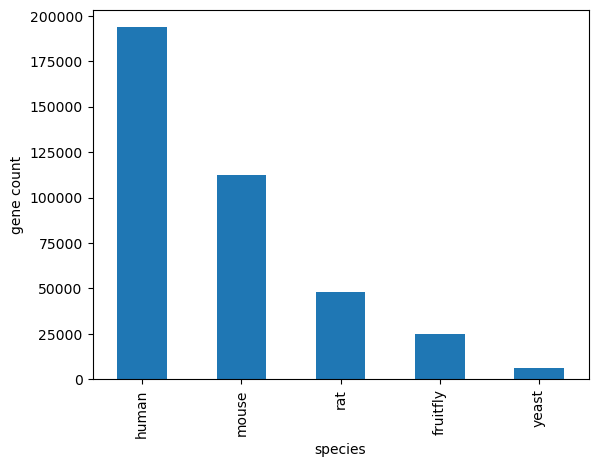

In [12]:
#genes per species

#build the dataframe
data = {'counts' : [human_df.shape[0],mouse_df.shape[0],rat_df.shape[0],fruitfly_df.shape[0],yeast_df.shape[0]]}
df = pd.DataFrame(data)
df.index = ['human', 'mouse','rat','fruitfly','yeast']

#show the first few lines of the dataframe
print(df.head())

#plot a basic bar-plot
df.plot.bar(ylabel='gene count',xlabel='species',legend=False)

### Info on bar of gene counts:
- There are more chromosones in a human and yeast
- This does not compensate for the difference in genome size

already downloaded, skipping download
               size  counts        norm
human     3298.4300  193686   58.720664
mouse     2728.2200  112310   41.166035
rat       2849.5800   47817   16.780368
fruitfly   143.7260   25079  174.491741
yeast       12.1571    6514  535.818575


<Axes: xlabel='species', ylabel='normalised gene count'>

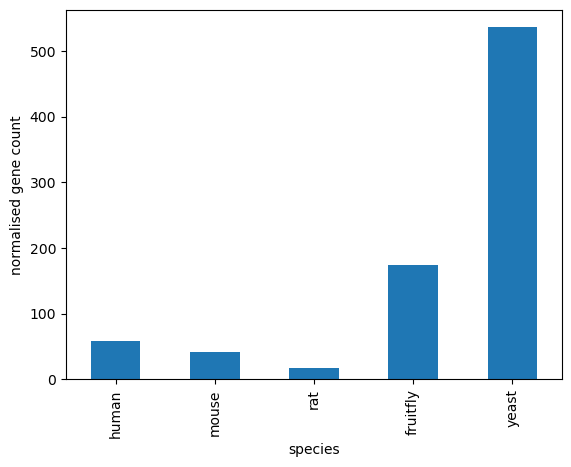

In [15]:
# Now we're going to look at the size of the genomes
if os.path.exists('data/genomes.txt'):
    print('already downloaded, skipping download')
else:
    print('Downloading: ' + 'data/genomes.txt' + '...')
    ul.request.urlretrieve('https://ftp.ncbi.nlm.nih.gov/genomes/GENOME_REPORTS/overview.txt','data/genomes.txt')



#build the genomes report dataframe
genomes_df = pd.read_csv('data/genomes.txt',header=0,sep='\t',low_memory=False)

#select the genome sizes from the dataframe
genome_sizes = {'size': [genomes_df[genomes_df[genomes_df.columns[0]].str.fullmatch('Homo sapiens')]['Size (Mb)'].astype('float').values[0], genomes_df[genomes_df[genomes_df.columns[0]].str.fullmatch('Mus musculus')]['Size (Mb)'].astype('float').values[0], genomes_df[genomes_df[genomes_df.columns[0]].str.fullmatch('Rattus norvegicus')]['Size (Mb)'].astype('float').values[0], genomes_df[genomes_df[genomes_df.columns[0]].str.fullmatch('Drosophila melanogaster')]['Size (Mb)'].astype('float').values[0], genomes_df[genomes_df[genomes_df.columns[0]].str.fullmatch('Saccharomyces cerevisiae')]['Size (Mb)'].astype('float').values[0]]}

#build the genome size dataframe
genomes = pd.DataFrame(genome_sizes)

#add the species index
genomes.index = ['human', 'mouse','rat','fruitfly','yeast']

#normalise gene number by genome size and plot

#combine the two dfs - genomes and df
final = pd.merge(genomes,df,left_index=True,right_index=True)

#normalise the gene counts
final['norm'] = final['counts']/final['size']

#view the final df
print(final)

#plot the normalised gene counts
final.plot.bar(ylabel='normalised gene count',xlabel='species',legend=False,y='norm')

#brief conclusion - both fly and yeast have compressed genomes compared to the mammals

### Insight from gene size normalized gene counts:
- Nearly all of the yeast genes are protein coding e.g. there is an intense selection for efficient coding and replication 
- 

In [ ]:
# Exploring unique transcripts from genome annotation

# This is the URL of the human refseq RNA file that contains the information displayed on the RefSeq website when you restrict it to homo_sapiens. You can find the number of unique transcripts from this by following a similar approach to above.
# I will not do this here, it is something you can develop as practice. NB that the file is >300Mb !

# https://ftp.ncbi.nlm.nih.gov/genomes/refseq/vertebrate_mammalian/Homo_sapiens/annotation_releases/current/GCF_000001405.40-RS_2023_10/GCF_000001405.40_GRCh38.p14_rna.gbff.gz

# You might like to explore the genomes FTP data site - https://ftp.ncbi.nlm.nih.gov/genomes